In [4]:
# Import libraries
import sys
import os
sys.path.insert(0, 'semantic_correspondence/src')

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
import torch
from torchvision import transforms

from spair_dataset import SPair71k
from model_config import MODEL_CONFIGS
from resized_dataset import ResizedSPairDataset

In [5]:
# Load the SPair-71k dataset
print("Loading SPair-71k dataset...")
builder = SPair71k(config_name="pairs")
builder.download_and_prepare()
dataset = builder.as_dataset()

print(f"\nDataset loaded successfully!")
print(f"Dataset splits: {dataset.keys()}")
print(f"Training set size: {len(dataset['train'])} pairs")
print(f"\nDataset features: {dataset['train'].features.keys()}")

Loading SPair-71k dataset...

Dataset loaded successfully!
Dataset splits: dict_keys(['train', 'validation', 'test'])
Training set size: 53340 pairs

Dataset features: dict_keys(['pair_id', 'src_img', 'src_segmentation', 'src_data_index', 'src_name', 'src_imsize', 'src_bndbox', 'src_pose', 'src_kps', 'trg_img', 'trg_segmentation', 'trg_data_index', 'trg_name', 'trg_imsize', 'trg_bndbox', 'trg_pose', 'trg_kps', 'kps_ids', 'category', 'category_id', 'viewpoint_variation', 'scale_variation', 'truncation', 'occlusion'])


# Visualize SPair-71k samples
The cell below displays a few sample image pairs from the `train` split. It shows the source and target images side-by-side and overlays keypoints (red) and bounding boxes (green) when available. Run the previous cells first so `dataset` is defined.

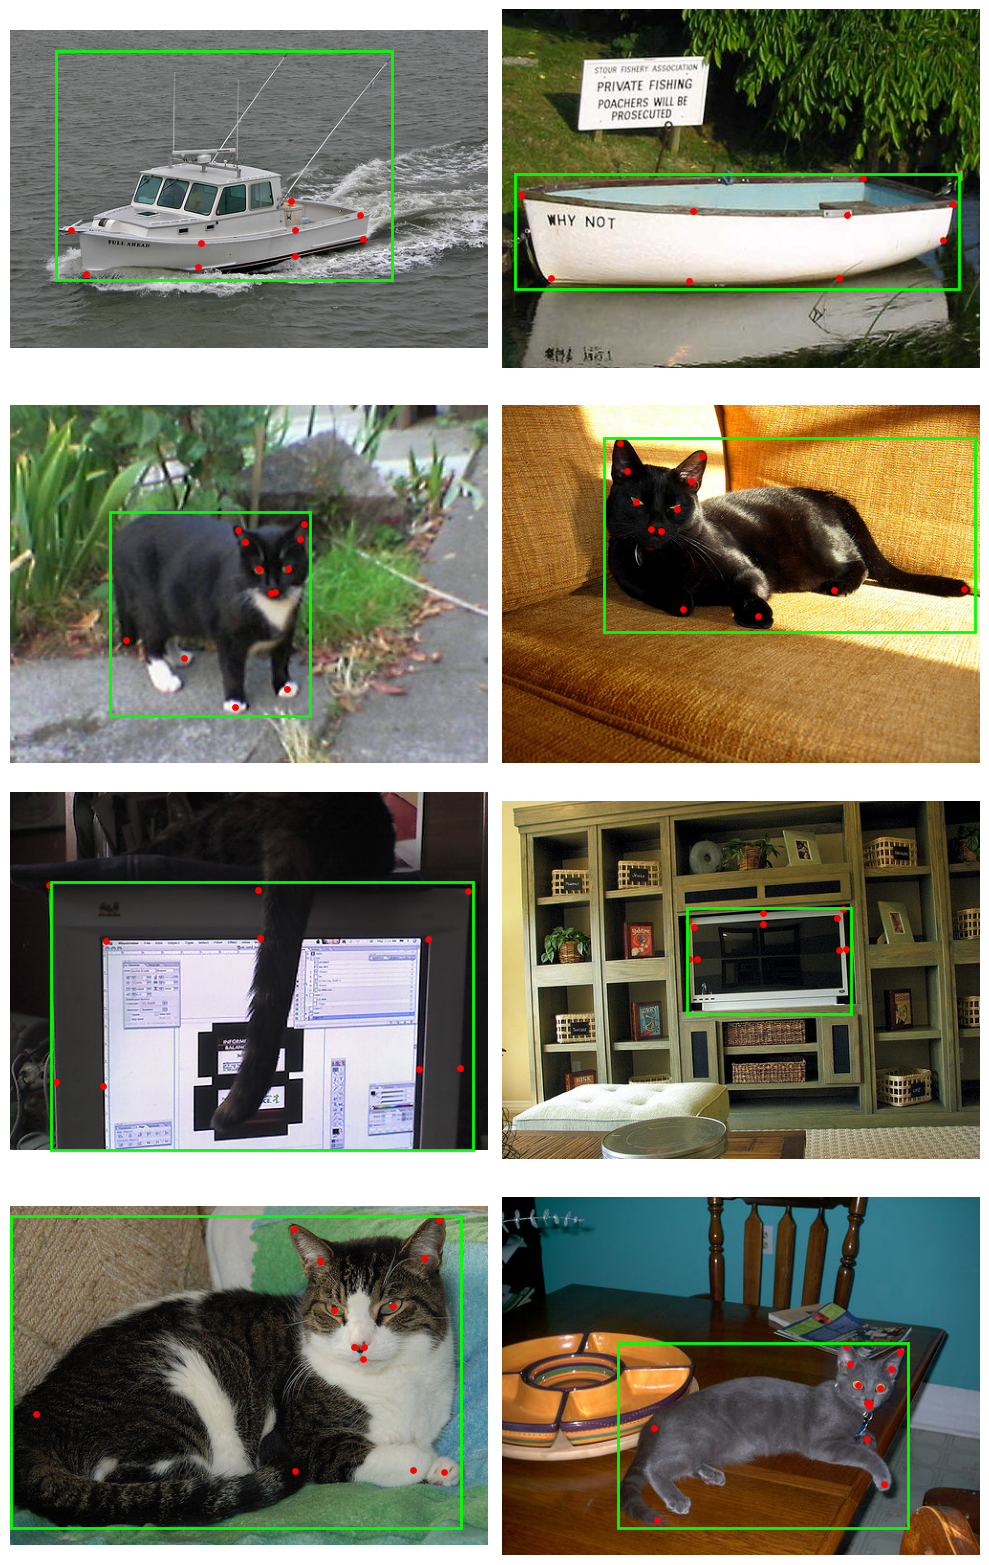

In [6]:
# Visualize a few sample pairs
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

def load_img(img_obj):
    # dataset may store images as dicts with a 'path' key or as PIL images
    if isinstance(img_obj, dict) and 'path' in img_obj:
        return Image.open(img_obj['path']).convert('RGB')
    return img_obj

def draw_bbox(ax, bbox):
    if bbox is None or len(bbox) == 0:
        return
    # SPair bbox format: [xmin, ymin, xmax, ymax] or similar; attempt to handle both
    try:
        x0, y0, x1, y1 = bbox
        w = x1 - x0
        h = y1 - y0
        rect = patches.Rectangle((x0, y0), w, h, linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
    except Exception:
        # fallback: treat as [x, y, w, h]
        try:
            x, y, w, h = bbox
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
        except Exception:
            return

def plot_pair(sample, ax_left, ax_right):
    src = load_img(sample.get('src_img'))
    trg = load_img(sample.get('trg_img'))
    ax_left.imshow(src)
    ax_left.axis('off')
    ax_right.imshow(trg)
    ax_right.axis('off')

    # keypoints (if available)
    src_kps = sample.get('src_kps')
    trg_kps = sample.get('trg_kps')
    if src_kps is not None and len(src_kps):
        kps = np.array(src_kps)
        ax_left.scatter(kps[:,0], kps[:,1], c='r', s=15)
    if trg_kps is not None and len(trg_kps):
        kps = np.array(trg_kps)
        ax_right.scatter(kps[:,0], kps[:,1], c='r', s=15)

    # bounding boxes (if available)
    draw_bbox(ax_left, sample.get('src_bndbox'))
    draw_bbox(ax_right, sample.get('trg_bndbox'))

# Show a few samples from the train split
n = 4
fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))
for i in range(n):
    sample = dataset['train'][i]
    plot_pair(sample, axes[i,0], axes[i,1])

plt.tight_layout()
plt.show()

In [7]:
# Display sample information
print("Sample data structure:")
sample = dataset['train'][0]
for key, value in sample.items():
    if isinstance(value, (list, tuple)):
        print(f"  {key}: {type(value).__name__} of length {len(value)}")
    else:
        print(f"  {key}: {type(value).__name__}")


Sample data structure:
  pair_id: int
  src_img: JpegImageFile
  src_segmentation: PngImageFile
  src_data_index: int
  src_name: str
  src_imsize: list of length 3
  src_bndbox: list of length 4
  src_pose: int
  src_kps: list of length 9
  trg_img: JpegImageFile
  trg_segmentation: PngImageFile
  trg_data_index: int
  trg_name: str
  trg_imsize: list of length 3
  trg_bndbox: list of length 4
  trg_pose: int
  trg_kps: list of length 9
  kps_ids: list of length 9
  category: str
  category_id: int
  viewpoint_variation: int
  scale_variation: int
  truncation: int
  occlusion: int


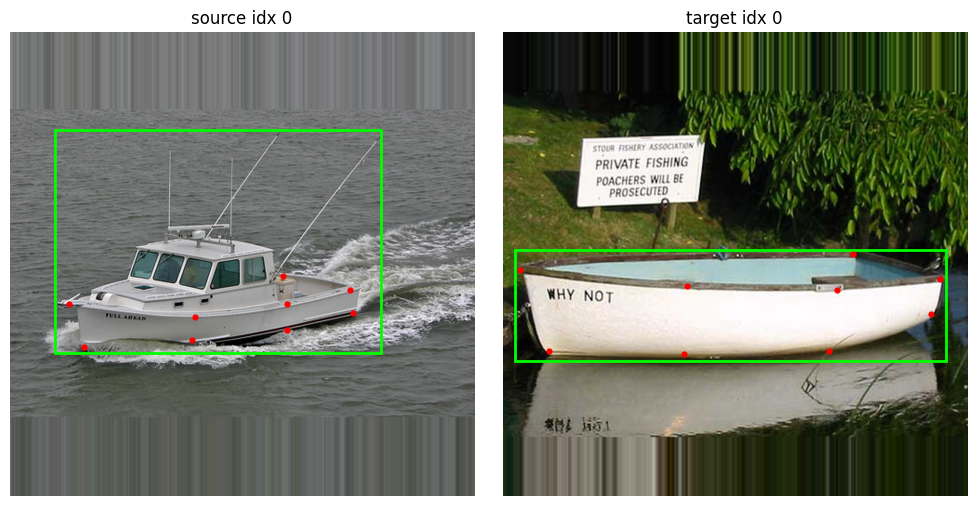

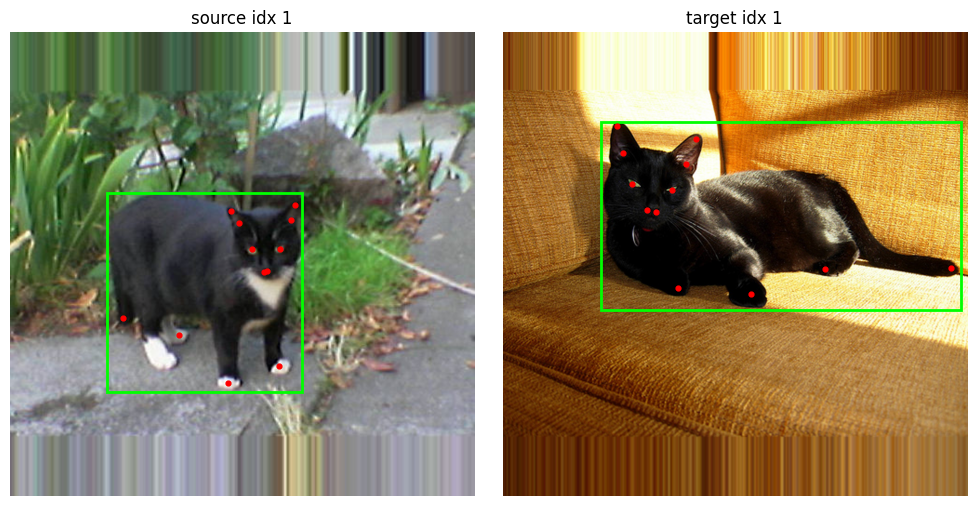

In [8]:
# Visualize resized samples (images, bboxes, keypoints)
cfg = MODEL_CONFIGS['dinov2']
resized_train = ResizedSPairDataset(dataset['train'], config=cfg)

from torchvision import transforms as _tv_transforms
import torch as _torch
import numpy as _np

def _unnormalize_to_pil(img_tensor, mean, std):
    mean_t = _torch.tensor(mean).view(-1, 1, 1)
    std_t = _torch.tensor(std).view(-1, 1, 1)
    img = img_tensor.detach().cpu() * std_t + mean_t
    img = _torch.clamp(img, 0, 1)
    return _tv_transforms.ToPILImage()(img)

def _maybe_plot_kps(ax, kps):
    if kps is None:
        return
    if isinstance(kps, _torch.Tensor):
        if kps.numel() == 0:
            return
        pts = kps.detach().cpu().numpy()
    else:
        if len(kps) == 0:
            return
        pts = _np.array(kps)
    ax.scatter(pts[:, 0], pts[:, 1], c='r', s=12)

def show_resized_pair(ds, idx=0, title=None):
    sample = ds[idx]
    src_img = _unnormalize_to_pil(sample['src_img'], cfg.mean, cfg.std)
    trg_img = _unnormalize_to_pil(sample['trg_img'], cfg.mean, cfg.std)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for ax, img, bbox, kps, label in [
        (axes[0], src_img, sample.get('src_bbox'), sample.get('src_kps'), 'source'),
        (axes[1], trg_img, sample.get('trg_bbox'), sample.get('trg_kps'), 'target'),
    ]:
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"{label} idx {idx}" if title is None else f"{title} — {label}")
        # bounding box
        if bbox is not None:
            if isinstance(bbox, _torch.Tensor):
                bbox_vals = bbox.detach().cpu().tolist()
            else:
                bbox_vals = list(bbox)
            if len(bbox_vals) == 4 and max(bbox_vals) > 0:
                x0, y0, x1, y1 = bbox_vals
                w, h = x1 - x0, y1 - y0
                rect = patches.Rectangle((x0, y0), w, h, linewidth=2, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
        _maybe_plot_kps(ax, kps)
    plt.tight_layout()
    plt.show()

# Display a couple of resized pairs
show_resized_pair(resized_train, idx=0)
show_resized_pair(resized_train, idx=1)

In [10]:
# Verify DINOv2 feature extraction on a resized sample pair
import torch
from dinov2_featuers import DINOv2FeatureExtractor

device = 'cuda' if torch.cuda.is_available() else 'cpu'
extractor = DINOv2FeatureExtractor(model_name='dinov2_vits14', device=device)

def describe_features(features, label):
    feats = features.detach().cpu()
    grid_h, grid_w = feats.shape[-2], feats.shape[-1]
    expected = cfg.size // extractor.patch_size
    print(f"{label}: shape={tuple(feats.shape)}, mean={feats.mean().item():.4f}, std={feats.std().item():.4f}")
    print(f"  grid {grid_h}x{grid_w}, expected {expected}x{expected}")

sample_idx = 0
sample_keypairs = [('src', resized_train[sample_idx]['src_img']), ('trg', resized_train[sample_idx]['trg_img'])]

for label, tensor in sample_keypairs:
    tensor = tensor.unsqueeze(0).to(device)
    desc = f"{label} sample {sample_idx}"
    feats = extractor.extract_features(tensor)
    describe_features(feats, desc)


Loading dinov2_vits14 on cpu...


Using cache found in /home/vscode/.cache/torch/hub/facebookresearch_dinov2_main


src sample 0: shape=(1, 384, 60, 60), mean=0.0007, std=0.0510
  grid 60x60, expected 60x60
trg sample 0: shape=(1, 384, 60, 60), mean=0.0012, std=0.0510
  grid 60x60, expected 60x60


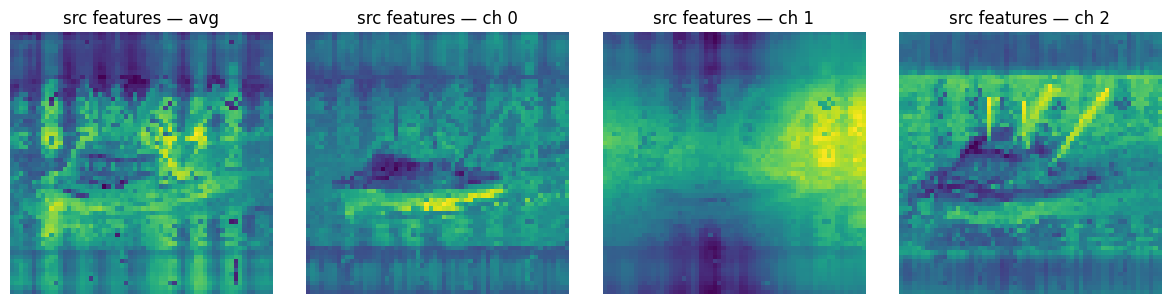

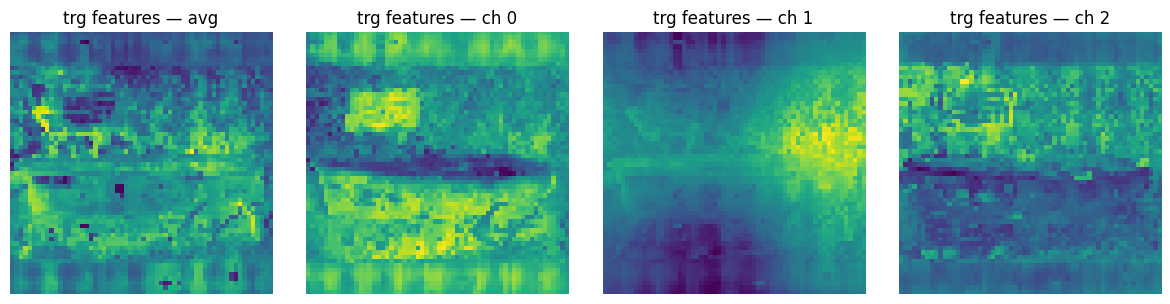

In [11]:
# Plot DINOv2 feature maps for the same resized pair
import matplotlib.pyplot as plt

def show_feature_grid(features, title):
    features = features.detach().cpu()
    avg_map = features.mean(dim=1).squeeze(0).numpy()
    channels = min(3, features.shape[1])
    channel_maps = [features[0, ch].numpy() for ch in range(channels)]
    all_maps = [avg_map] + channel_maps
    fig, axes = plt.subplots(1, len(all_maps), figsize=(3 * len(all_maps), 3))
    if not hasattr(axes, '__iter__') or isinstance(axes, plt.Axes):
        axes = [axes]
    for ax, fmap, label in zip(axes, all_maps, ['avg'] + [f'ch {i}' for i in range(channels)]):
        ax.imshow(fmap, cmap='viridis', interpolation='nearest')
        ax.set_title(f"{title} — {label}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

sample_idx = 0
sample_keypairs = [('src', resized_train[sample_idx]['src_img']), ('trg', resized_train[sample_idx]['trg_img'])]
for label, tensor in sample_keypairs:
    tensor = tensor.unsqueeze(0).to(device)
    feats = extractor.extract_features(tensor)
    show_feature_grid(feats, f"{label} features")